In [6]:
import yaml
from util.config_utils import load_yaml

cfg = load_yaml('configs/rule_loss.yaml')

cfg.rules.__dict__

{'name': '8693_full',
 'mode': 'soft',
 'recall_threshold': 0.8,
 'constraint_weight': 1}

In [4]:
import numpy as np
prec = np.array([1,2,3,4,5])
print(prec)
print(prec[None, :])

vals = np.array([[1,0,0,1,0],
                 [0,1,0,1,1]])
mask = vals.astype(bool)

result = np.where(mask, prec[None, :], 0)

print(result)



[1 2 3 4 5]
[[1 2 3 4 5]]
[[1 0 0 4 0]
 [0 2 0 4 5]]


In [ ]:

    with open(rules_json, 'r') as f:
        rules = json.load(f)

In [60]:
import torch
import torch.nn.functional as F

def generate_probability_distribution(d):
    # Generate a random vector of size d
    random_vector = torch.rand(d)
    # Normalize the vector to sum to 1
    probability_distribution = random_vector/random_vector.sum()
    return probability_distribution

# Example usage
d = 5

neural = generate_probability_distribution(d)
rule = generate_probability_distribution(d)
prior = generate_probability_distribution(d)

# Sort all distributions by the 'prior' distribution
sorted_indices = torch.argsort(prior, descending=True)

neural = neural[sorted_indices]
rule = rule[sorted_indices]
prior = prior[sorted_indices]

print(neural)
print(rule)
print(prior)

tensor([0.1885, 0.0010, 0.2804, 0.2944, 0.2357])
tensor([0.2376, 0.2523, 0.2275, 0.0851, 0.1974])
tensor([0.4496, 0.3204, 0.1043, 0.0698, 0.0560])


tensor([0.4314, 0.2836, 0.5089, 0.3367, 0.4401])


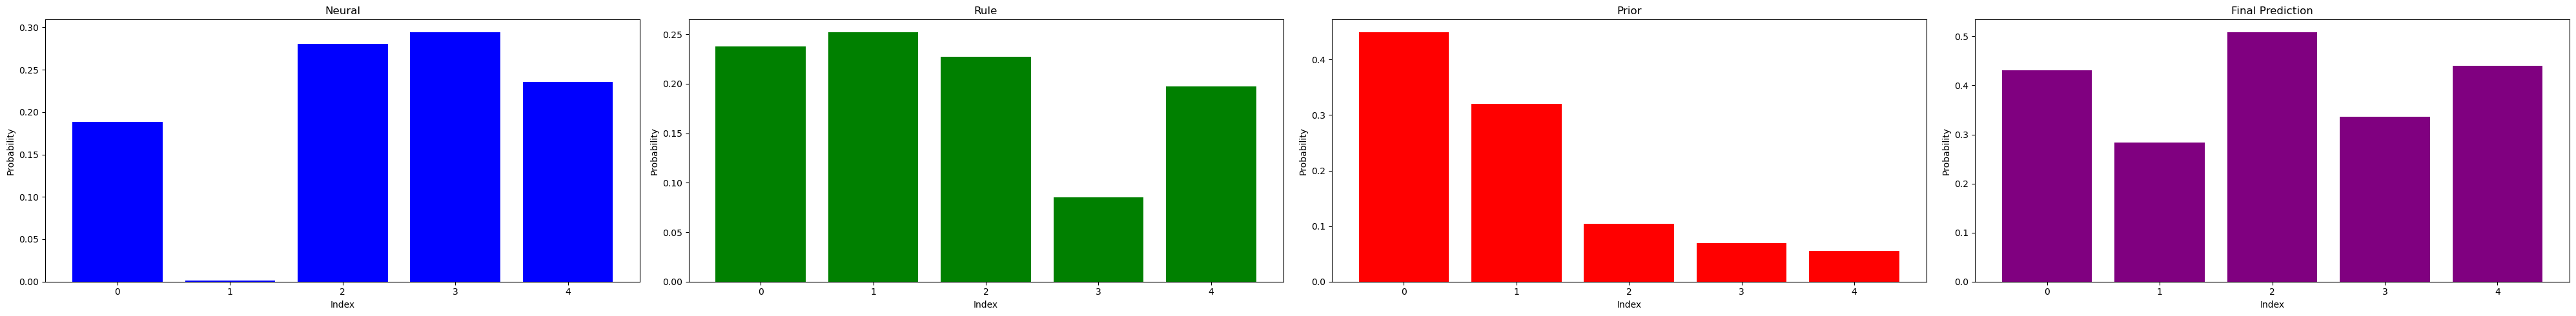

: 

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(distribution, title, color, position, n, d):
    plt.subplot(1, n, position)
    plt.bar(range(d), distribution.numpy(), color=color)
    plt.title(title)
    plt.xlabel('Index')
    plt.ylabel('Probability')

def plot_distributions(distributions, titles, colors, d):
    n = len(distributions)
    plt.figure(figsize=(10 * n, 5))
    for i, (distribution, title, color) in enumerate(zip(distributions, titles, colors), start=1):
        plot_distribution(distribution, title, color, i, n, d)
    plt.tight_layout()
    plt.show()


# Calculate the final prediction by weighting the rule and neural distributions based on the prior distribution.
# The rarer the class (lower prior probability), the more we trust the rules.
# The more common the class (higher prior probability), the more we trust the neural network.

# # Introduce scaling hyperparameters for rule and neural
# rule_scale = 0.5  # Example scaling factor for rule
# neural_scale = 0.5  # Example scaling factor for neural

# # Calculate weights for rule and neural based on the prior distribution
# rule_weight = (1 - prior) * rule_scale
# neural_weight = prior * neural_scale

# # Normalize the weights
# total_weight = rule_weight + neural_weight
# rule_weight /= total_weight
# neural_weight /= total_weight

# # Compute the final prediction
# final_prediction = (rule * rule_weight + neural * neural_weight)
# #final_prediction = F.softmax(final_prediction, dim=0)
# final_prediction = final_prediction / final_prediction.sum(dim=0)


k = 0.1
final_prediction = (rule * (1/prior)**k) + (neural * prior**k)

#print(final_prediction.sum())
print(final_prediction)








# Plot all distributions side by side
plot_distributions(
    distributions=[neural, rule, prior, final_prediction],
    titles=['Neural', 'Rule', 'Prior', 'Final Prediction'],
    colors=['blue', 'green', 'red', 'purple'],
    d=d
)


In [ ]:
import torch 
a = torch.tensor([2,2,2,2,2])
b = torch.tensor([1,2,3,4,5])

c = a ** b
print(c)







tensor([ 2,  4,  8, 16, 32])


: 

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-text-to-text", model="allenai/Molmo-7B-D-0924", trust_remote_code=True)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/p-blog/candy.JPG"},
            {"type": "text", "text": "What animal is on the candy?"}
        ]
    },
]
pipe(text=messages)

In [3]:
torch.randint(0, 2, (10, 3))

tensor([[0, 0, 1],
        [0, 0, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 1],
        [0, 1, 0],
        [0, 1, 0],
        [1, 0, 1],
        [0, 0, 0],
        [0, 0, 0]])

In [ ]:
from torchmetrics import MetricCollection, Precision, Recall, F1Score, Accuracy, AveragePrecision
import torch

X_logits = torch.randn(10, 3) # logits
#X_probs = torch.sigmoid(X_logits)
y_targets = torch.randint(0, 2, (10, 3)) # targets

num_relations = 3
train_edge_metrics = MetricCollection({
            'edge_precision': Precision(task='multilabel', num_labels=num_relations, average='macro'),
            'edge_recall': Recall(task='multilabel', num_labels=num_relations, average='macro'),
            'edge_f1': F1Score(task='multilabel', num_labels=num_relations, average='macro'),
            'edge_accuracy': Accuracy(task='multilabel', num_labels=num_relations),
            'edge_mAP': AveragePrecision(task='multilabel', num_labels=num_relations, average='macro'),
        })

metrics = train_edge_metrics(X_logits, y_targets)
print(metrics)

{'edge_accuracy': tensor(0.3333), 'edge_f1': tensor(0.2738), 'edge_mAP': tensor(0.5456), 'edge_precision': tensor(0.3333), 'edge_recall': tensor(0.2778)}


: 